## Week 2 Assignment — Getting Started with PyTorch

## Pytorch Setup

Run the cell below first to confirm PyTorch is working. If it prints a version number, you're ready to go.


In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.12.0
GPU available: False


In [2]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 6.9 MB/s  0:00:12m0:00:0100:01


---
### Part A — Warm-Up Concepts

Answer in your own words, **2–3 sentences each**. No code needed here — this just checks the reading made sense. Double-click each answer cell to edit it.


**A1.** What is a **tensor**, and how is it different from a normal Python list? Give one everyday example of data that could be stored as a tensor.

_Your answer: tensor is a multi-dimensional array used to store data. Literally any kind of data can be stored inside a tensor such as a  any image can be represented using tensors. every pixel in that image can correspond to a number inside the tensor



**A2.** What do the terms **shape**, **ndim** (dimensions), and **dtype** tell you about a tensor?

_Your answer:_ ndim tells us the number of dimensions(axis) of the tensor(equal to number of square brackets) . Shape tells us the exact size of the tensor, its a tuple like (3,5) etc. dtype tells us the data type of the elements inside the tensor.



**A3.** Why do we sometimes move tensors and models to a **GPU**? What problem does it solve?

_Your answer:_ GPU (Graphics Processing Unit) helps leverage parallel processing for massive mathematical workloads.



**A4.** In machine learning, what is the difference between **training data** and **test data**, and why must we keep them separate?

_Your answer:_ Training data is the dataset on which we train the model by applying optimization tools like backpropagation and gradient descent, while test data is used at the very end to evaluate whether our training was successful on unseen information. Keeping them separate is absolutely critical because evaluating the model on the same data it learned from risks overfitting


**A5.** In your own words, what is a model actually *"learning"* when we train it? (Hint: think about weights and bias.)

_Your answer:_ When we train a model, it is actually learning the optimal values for its weights and biases by adjusting them using optimization tools like gradient descent. The model continuously checks its predictions against the true labels using a loss function to calculate its error, and then modifies these weights and biases in order to minimize that error and make more accurate future predictions.


---
### Part B — Tensor Basics

Write code for each task in the cell below it. **Print the result of every step** so we can see the output.


**B1.** Create a tensor of the numbers 1 to 10. Print its **shape**, **number of dimensions**, and **dtype**.

In [7]:
# TODO: create the tensor and print shape, ndim, and dtype
zeros = torch.zeros(size = (1,10))
print(zeros.shape)
print(zeros.ndim)
print(zeros.dtype)
zeros

torch.Size([1, 10])
2
torch.float32


tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

**B2.** Create a random tensor of shape **(3, 4)**. Then create another of shape **(4, 2)** and perform a **matrix multiplication** between them. Print the shape of the result.

In [9]:
# TODO: create two tensors and matrix-multiply them
M1 = torch.rand(size = (3,4))
M2 = torch.rand(size = (4,2))   
M3 = torch.matmul(M1,M2)
M3.shape

torch.Size([3, 2])

**B3.** Take your random (3, 4) tensor and find its **minimum, maximum, mean, and sum**.

In [11]:
# TODO: min / max / mean / sum
random = torch.rand(size = (3,4))
print(random.max())
print(random.min())
print(random.mean())
print(random.sum())

tensor(0.9380)
tensor(0.0333)
tensor(0.4540)
tensor(5.4486)


**B4.** Create a tensor with values from **0 to 100 in steps of 10**, then **reshape** it into shape **(2, 5)**.

In [15]:
# TODO: create with torch.arange, then reshape
initial = torch.arange(0,100,10)
initial
initial.reshape(2,5)

tensor([[ 0, 10, 20, 30, 40],
        [50, 60, 70, 80, 90]])

**B5.** Set the random **seed to 42**, create a random **(2, 3)** tensor, then explain in one line (in the markdown cell after) why setting a seed is useful.

In [29]:
# TODO: set seed, then create the tensor
torch.manual_seed(42)
random_tensor = torch.rand(2, 3)
print(random_tensor)

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])


**B5 explanation:** _Why is setting a random seed useful?_
A random seed basically ensures that the same tensor would be output regardless of how many times we execute the block of code. 
This is useful as it ensures that whenever we make changes to the rest of the code , the final output dosent get influenced by the random tensor.

---
### Part C — Mini-Project: Your First Model

This is the main event. You'll build a tiny model that learns a **straight line** — the classic *"hello world"* of deep learning. Follow the workflow from **Section 01** step by step.

### The goal
We'll invent some data that follows the rule **y = 0.7 × x + 0.3**. Your model doesn't know those numbers — its job is to **learn them from the data alone**. Run the cell below to create the data.


In [48]:
import torch

# The "true" values our model will try to discover
weight, bias = 0.7, 0.3

# Create the data
X = torch.arange(0, 1, 0.02).unsqueeze(1)   # inputs,  shape: (50, 1)
y = weight * X + bias                        # outputs, shape: (50, 1)

print("X shape:", X.shape, "| y shape:", y.shape)
print("First 5 X values:", X[:5].squeeze())
print("First 5 y values:", y[:5].squeeze())

X shape: torch.Size([50, 1]) | y shape: torch.Size([50, 1])
First 5 X values: tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800])
First 5 y values: tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560])


### Your tasks

**C1.** Split the data into a **training set (first 80%)** and a **test set (last 20%)**. Print how many samples are in each.

In [49]:
# TODO: split X and y into X_train, y_train, X_test, y_test
# Hint: 80% of 50 samples = 40
train_split = int(0.8*(len(X)))
X_train, y_train = X[:train_split] , y[:train_split]
X_test , y_test = X[train_split:] , y[train_split:]
print(len(X_test))
print(len(y_test))
print(len(X_train))
print(len(y_train))



10
10
40
40


**C2.** Build a simple **model** using `torch.nn.Module` (or `nn.Linear`) that takes one input and produces one output.

In [50]:
from torch import nn
# TODO: define your model class (or use nn.Linear(1, 1))
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1), requires_grad=True)

    def forward(self, x):
        return self.weights * x + self.bias

**C3.** Pick a **loss function** (try `nn.L1Loss`) and an **optimizer** (try `torch.optim.SGD` with a small learning rate like 0.01).

In [51]:
# TODO: create the model instance, loss_fn, and optimizer
torch.manual_seed(42)
model = MyModel()

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

**C4.** Write a **training loop** for about **200 epochs**. In each loop: make predictions, calculate the loss, zero the gradients, backpropagate, and step the optimizer. **Print the epoch and loss every 20 epochs.**

In [52]:
# TODO: training loop
epochs = 200
for epoch in range(epochs):
   model.train()
   y_pred = model(X_train)
   loss = loss_fn(y_pred, y_train)
   optimizer.zero_grad()
   loss.backward()
   optimizer.step()

   if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


Epoch 0 | Loss: 0.3129
Epoch 20 | Loss: 0.0891
Epoch 40 | Loss: 0.0454
Epoch 60 | Loss: 0.0382
Epoch 80 | Loss: 0.0313
Epoch 100 | Loss: 0.0245
Epoch 120 | Loss: 0.0176
Epoch 140 | Loss: 0.0107
Epoch 160 | Loss: 0.0039
Epoch 180 | Loss: 0.0089


**C5.** After training, print the model's **learned weight and bias**. How close are they to **0.7** and **0.3**?

In [53]:
# TODO: print the learned parameters
# Hint: list(model.parameters()) or model.state_dict()
print(model.state_dict())


OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})


**C6.** Make **predictions on the test set**, and (optional nicety) **plot** the predictions against the actual values with matplotlib.

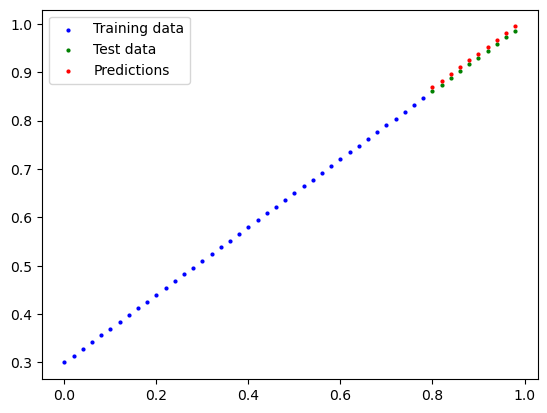

In [59]:
import matplotlib.pyplot as plt

# TODO: predict on X_test (use torch.inference_mode()) and plot
with torch.inference_mode():
    y_preds = model(X_test)



plt.scatter(X_train, y_train, c="b", s=4, label="Training data")

plt.scatter(X_test, y_test, c="g", s=4, label="Test data")

plt.scatter(X_test, y_preds, c="r", s=4, label="Predictions")

plt.legend()
plt.show()

### ✅ What success looks like
- Your **loss value gets smaller** as training goes on.
- Your **learned weight and bias** end up close to **0.7** and **0.3**.
- You can explain, in a sentence, what your training loop is doing.
trainng loop finds the error using loss function, keeps minimizing the error using optimization functions.

---
### Part D — Reflection

A few honest sentences — this helps us help you next week.


**D1.** What was the single **most confusing** thing this week, and how did you (try to) figure it out?

_Your answer:_ it was understanding the syntax, the syntax does get weird at some parts 



**D2.** Which of the five training-loop steps (predict → loss → zero gradients → backprop → step) still feels **fuzzy**?

_Your answer:_ the backprop and the mathematics behind it 



**D3.** On a scale of **1–5**, how comfortable do you feel with tensors now? One line on why.

_Your answer:_ i still am not very comfortable with syntax so 3.5



---
## ⭐ Bonus (Optional)

Only if you finished the rest and want a challenge:

- Change the learning rate to a **much larger** value (e.g. `1.0`) and a **much smaller** one (e.g. `0.0001`). What happens to the loss in each case? Write 2–3 sentences on what you observed.
- Peek at **Section 02 (Neural Network Classification)** and write down **one new idea** you noticed that wasn't in this week's work.


In [ ]:
# (Optional) Bonus experiments here


**Bonus notes:** _What did you observe?_

